# Student Performance Prediction using Machine Learning
**Student Name:** Mukhammadsaiid Norbaev  
**Student ID:** NOR22597897  
**Module:** Data Science – Coursework 2  

---
This notebook implements and evaluates machine learning models to predict whether a student will pass or fail, building directly on the dataset and proposals from Coursework 1. The primary model is Naive Bayes (as proposed in CW1), with Logistic Regression added as an extension for comparison and deeper feature analysis.

## 1. Import Libraries and Load Dataset

All required libraries are imported here. The dataset loaded is the cleaned version prepared in Coursework 1, with the updated Pass threshold applied. Loading it at the start ensures all subsequent cells work from a consistent data state.

In [1]:
# Import core data manipulation library
import pandas as pd

# Import numerical computing library (used for array operations)
import numpy as np

# Import train-test split: separates data so model is evaluated on unseen examples
from sklearn.model_selection import train_test_split

# Import Min-Max scaler: normalises all features to the same [0,1] range
# This prevents features with larger magnitudes from dominating model training
from sklearn.preprocessing import MinMaxScaler

# Import Gaussian Naive Bayes: the primary model proposed in Coursework 1
# Gaussian variant handles continuous (numerical) features after scaling
from sklearn.naive_bayes import GaussianNB

# Import Logistic Regression: extension model for comparison and feature analysis
from sklearn.linear_model import LogisticRegression

# Import evaluation metrics to assess model performance beyond simple accuracy
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Import visualisation libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Load the cleaned dataset (produced in Coursework 1 preprocessing stage)
df = pd.read_excel("NOR22597897_CleanedDataset_v2.xlsx")

# Display first few rows to confirm dataset loaded correctly
print("First 5 rows:")
df.head()

First 5 rows:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Pass
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,0
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,0
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,1
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,1
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,High,Public,Neutral,4,No,College,Near,Female,70,1


In [2]:
# Check structure: column names, data types, and missing value counts
# This confirms which columns have missing values that need handling
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [3]:
# Display basic statistics for all numerical columns
# Useful for understanding feature ranges before applying Min-Max normalisation
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Pass
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659,0.245951
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456,0.430682
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000,0.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000,0.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000,0.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000,0.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000,1.000000


## 2. Explore Target Variable (Exam Score Distribution)

Before creating the classification target, the distribution of Exam_Score is analysed. This step is important because the choice of pass/fail threshold depends on how scores are distributed. If most scores cluster above or below a threshold, the resulting class labels will be heavily imbalanced, which affects model evaluation.

Exam Score Statistics:
count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


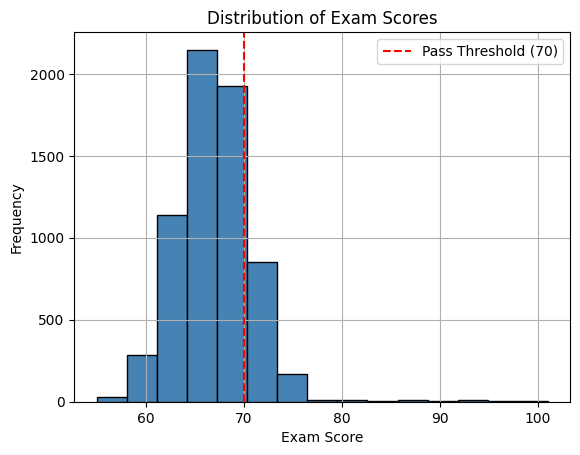


Students scoring >= 70: 1625
Students scoring < 70: 4982


In [4]:
# Summary statistics for Exam_Score to understand its distribution
print("Exam Score Statistics:")
print(df["Exam_Score"].describe())

# Histogram to visualise the shape of the score distribution
# The distribution shape directly informs the threshold selection:
# a threshold at the median creates the most balanced classes
df["Exam_Score"].hist(bins=15, color='steelblue', edgecolor='black')
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.axvline(x=70, color='red', linestyle='--', label='Pass Threshold (70)')
plt.legend()
plt.show()

# Count how many students score above and below threshold of 70
print(f"\nStudents scoring >= 70: {(df['Exam_Score'] >= 70).sum()}")
print(f"Students scoring < 70: {(df['Exam_Score'] < 70).sum()}")

## 3. Preprocessing: Redefine the Pass Variable

In Coursework 1, the Pass variable was initially set at a threshold of 50. However, since all exam scores in the dataset are 55 or above, this resulted in every student being classified as pass — making the dataset completely unsuitable for classification training.

The threshold is corrected to **70**, which aligns with a typical distinction/pass boundary and creates a meaningful class split. This produces approximately 75% fail and 25% pass — an imbalanced distribution that must be considered when interpreting accuracy scores, as a model that always predicts 'fail' would already achieve ~75% accuracy without learning anything meaningful.

Class Distribution (Pass variable):
Pass
0    4982
1    1625
Name: count, dtype: int64

Class balance: Pass
0    75.4
1    24.6
Name: proportion, dtype: float64%


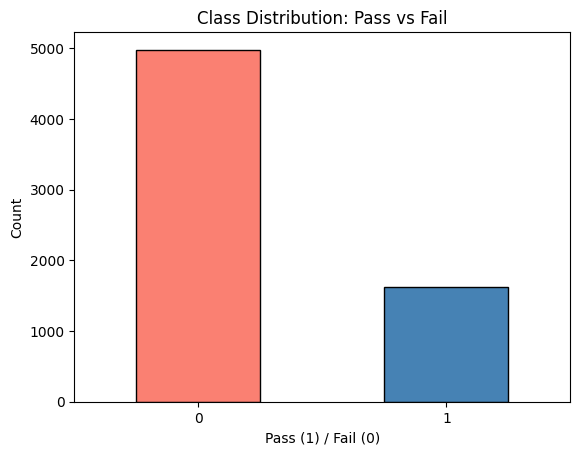

In [5]:
# Redefine Pass variable: 1 = pass (score >= 70), 0 = fail (score < 70)
# Threshold of 50 used in CW1 was incorrect as all scores were above 50
# Threshold of 70 creates a meaningful binary classification problem
df["Pass"] = (df["Exam_Score"] >= 70).astype(int)

# Inspect the class distribution to understand potential imbalance
# Important: a heavily skewed distribution affects how we interpret accuracy
print("Class Distribution (Pass variable):")
print(df["Pass"].value_counts())
print(f"\nClass balance: {df['Pass'].value_counts(normalize=True).round(3) * 100}%")

# Visualise class distribution
df["Pass"].value_counts().plot(kind='bar', color=['salmon', 'steelblue'], edgecolor='black')
plt.title("Class Distribution: Pass vs Fail")
plt.xlabel("Pass (1) / Fail (0)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## 4. Feature Selection

The dataset is split into input features (X) and the target variable (y).

**Exam_Score is explicitly removed from X** to prevent data leakage. Since Pass is derived directly from Exam_Score (using a threshold), keeping it as a feature would mean the model has access to the answer during training, producing unrealistically high accuracy that would not generalise to real-world unseen data.

In [6]:
# Remove both Pass (target) and Exam_Score (direct source of target) from features
# Keeping Exam_Score would be data leakage: the model would learn to reverse-engineer
# the threshold rather than learning from student behaviour and environment features
X = df.drop(columns=["Pass", "Exam_Score"])

# Target variable: binary label (0 = fail, 1 = pass)
y = df["Pass"]

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)} total):")
print(list(X.columns))

Features (X) shape: (6607, 19)
Target (y) shape: (6607,)

Feature columns (19 total):
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


## 5. Train-Test Split

The dataset is split into 80% training and 20% testing. The training set is used to fit the model; the test set simulates unseen data and is used exclusively for evaluation.

A fixed **random_state=42** ensures the split is identical every time the notebook is run, making results reproducible and comparable across model iterations.

In [7]:
# Split data: 80% for training, 20% for testing
# random_state=42 ensures the same split every run (reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,       # 20% held out for final evaluation
    random_state=42      # Fixed seed for reproducibility
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size:  {X_test.shape[0]} samples")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"\nClass distribution in test set:")
print(y_test.value_counts())

Training set size: 5285 samples
Testing set size:  1322 samples

Class distribution in training set:
Pass
0    4008
1    1277
Name: count, dtype: int64

Class distribution in test set:
Pass
0    974
1    348
Name: count, dtype: int64


## 6. Encoding Categorical Variables

Categorical features (e.g. Motivation_Level, School_Type, Gender) are converted into numerical format using **one-hot encoding**. This creates a binary column for each category value, allowing machine learning models to process them mathematically without implying any ordinal relationship between categories.

Encoding is applied separately to training and testing sets to prevent information from the test set influencing the training process. The `.align()` method ensures both sets have identical columns — essential because the same model must process both.

In [8]:
# Apply one-hot encoding to categorical features in both sets separately
# Encoding is done independently to prevent test data influencing training
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Align columns: ensures train and test have identical columns after encoding
# If a category appears only in training, test gets a 0 column (fill_value=0)
# join='left' keeps all training columns as the reference set
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# IMPORTANT: save column names now, before scaling converts DataFrame to numpy array
# These encoded column names are needed for correct feature importance mapping later
encoded_feature_names = X_train.columns.tolist()

print(f"Number of features after encoding: {len(encoded_feature_names)}")
print(f"Sample encoded feature names: {encoded_feature_names[:10]}")

Number of features after encoding: 40
Sample encoded feature names: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Parental_Involvement_High', 'Parental_Involvement_Low', 'Parental_Involvement_Medium', 'Access_to_Resources_High']


## 7. Feature Scaling (Min-Max Normalisation)

Min-Max normalisation transforms all feature values into the range [0, 1]. This is important because features with larger numerical ranges (e.g. Attendance: 60–100) could otherwise dominate features with smaller ranges (e.g. Sleep_Hours: 4–10), creating unfair weighting during model training.

Critically, the scaler is **fitted only on the training data** and then applied (not refitted) to the test data. Fitting on the test set would constitute data leakage — the model would have indirect knowledge of the test distribution before evaluation.

In [9]:
# Create scaler object (transforms values to range [0, 1])
scaler = MinMaxScaler()

# Fit scaler on training data only, then transform training set
# fit_transform: learns min/max from training data AND applies transformation
X_train = scaler.fit_transform(X_train)

# Apply the SAME transformation to test data (no re-fitting)
# Using test min/max would be data leakage - test set must remain completely unseen
X_test = scaler.transform(X_test)

print("Scaling applied successfully.")
print(f"Training data range after scaling: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"Test data range after scaling: [{X_test.min():.2f}, {X_test.max():.2f}]")

Scaling applied successfully.
Training data range after scaling: [0.00, 1.00]
Test data range after scaling: [0.00, 1.02]


## 8. Naive Bayes Model Training

Gaussian Naive Bayes is the primary model selected in Coursework 1. It is trained here on the preprocessed training data.

**Why GaussianNB?** The Gaussian variant assumes features follow a normal distribution — appropriate after Min-Max scaling has been applied to continuous features. It is computationally efficient and works well as a baseline classifier, especially when features are approximately independent.

In [10]:
# Instantiate Gaussian Naive Bayes model
# GaussianNB is used because features are continuous (after scaling)
# It models each feature as a Gaussian (normal) distribution per class
nb_model = GaussianNB()

# Train the model on the training data
# The model learns the probability distribution of each feature for each class (pass/fail)
nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


## 9. Naive Bayes – Predictions on Test Set

The trained Naive Bayes model is now used to generate predictions on the test set. These predictions are compared to the actual labels to evaluate model performance. The test set has never been seen by the model during training, so this provides a fair estimate of real-world performance.

In [11]:
# Generate predictions on the test set
# The model applies the learned probability distributions to classify each test sample
y_pred_nb = nb_model.predict(X_test)

print(f"Predictions generated for {len(y_pred_nb)} test samples.")
print(f"Predicted class distribution: {pd.Series(y_pred_nb).value_counts().to_dict()}")

Predictions generated for 1322 test samples.
Predicted class distribution: {0: 963, 1: 359}


## 10. Naive Bayes – Model Evaluation

Model performance is evaluated using three complementary metrics:

- **Accuracy**: Overall proportion of correct predictions. However, given the class imbalance (75% fail, 25% pass), a model that always predicts 'fail' would already achieve ~75% accuracy without learning anything. Accuracy alone is therefore insufficient.
- **Precision**: Of all students predicted to pass, how many actually did? Important for avoiding false positives (predicting pass for students who will fail).
- **Recall**: Of all students who actually passed, how many did the model correctly identify? Important for avoiding false negatives (missing students who need intervention).
- **F1-score**: Harmonic mean of precision and recall — a balanced single-number summary per class.

In [12]:
# Calculate overall accuracy
nb_accuracy = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {nb_accuracy:.4f} ({nb_accuracy*100:.1f}%)")

# Confusion matrix: shows the breakdown of correct and incorrect predictions per class
# Rows = actual class, Columns = predicted class
# [TN, FP]  = fail correctly predicted, fail incorrectly predicted as pass
# [FN, TP]  = pass incorrectly predicted as fail, pass correctly predicted
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

# Full classification report: precision, recall, and F1 broken down per class
# This is more informative than accuracy for imbalanced datasets
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8812 (88.1%)

Confusion Matrix:
[[890  84]
 [ 73 275]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.92       974
           1       0.77      0.79      0.78       348

    accuracy                           0.88      1322
   macro avg       0.85      0.85      0.85      1322
weighted avg       0.88      0.88      0.88      1322



## 11. Naive Bayes – Confusion Matrix Visualisation

The confusion matrix is visualised as a heatmap for clearer interpretation. Each cell shows:
- **Top-left (TN)**: Fail correctly predicted as fail
- **Top-right (FP)**: Fail incorrectly predicted as pass — students who will fail but receive no intervention
- **Bottom-left (FN)**: Pass incorrectly predicted as fail — students flagged unnecessarily
- **Bottom-right (TP)**: Pass correctly predicted as pass

In an educational context, **false positives (FP) are the most harmful error** — a student predicted to pass who actually fails would receive no support.

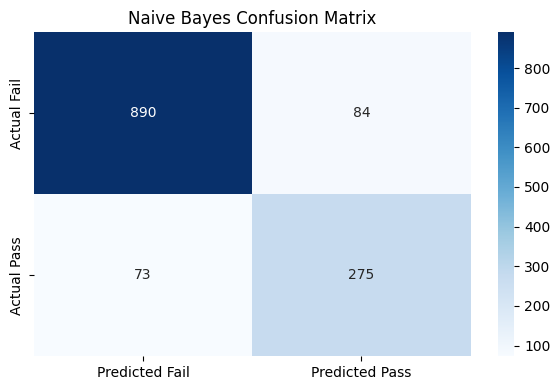

In [13]:
# Create confusion matrix heatmap for Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_nb,
    annot=True,          # Show numbers in each cell
    fmt="d",             # Integer format
    cmap="Blues",        # Colour scheme
    xticklabels=["Predicted Fail", "Predicted Pass"],
    yticklabels=["Actual Fail", "Actual Pass"]
)
plt.title("Naive Bayes Confusion Matrix")
plt.tight_layout()
plt.show()

## 12. Extension: Logistic Regression Model Training

Logistic Regression is implemented as an extension model — not to replace Naive Bayes, but to provide a comparison and to extract feature importance through model coefficients (which Naive Bayes cannot easily provide).

Unlike Naive Bayes, **Logistic Regression does not assume feature independence**. It models a weighted linear combination of all features, allowing it to capture correlations between variables such as Hours_Studied and Attendance.

`max_iter=1000` is set to ensure the solver has sufficient iterations to converge on the optimal weights for this dataset.

In [14]:
# Instantiate Logistic Regression model
# max_iter=1000 prevents convergence warnings on larger datasets
# The solver finds the optimal coefficients (weights) for each feature
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train on the same preprocessed training data as Naive Bayes
# Using identical training data ensures a fair comparison between models
lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## 13. Logistic Regression – Predictions on Test Set

The trained Logistic Regression model generates predictions on the same test set. Using the identical test set for both models is essential for a fair comparison — any difference in performance reflects the models' capabilities, not differences in the evaluation data.

In [15]:
# Generate predictions on the same test set used for Naive Bayes evaluation
# Using the same test set ensures model comparison is fair
y_pred_lr = lr_model.predict(X_test)

print(f"Predictions generated for {len(y_pred_lr)} test samples.")
print(f"Predicted class distribution: {pd.Series(y_pred_lr).value_counts().to_dict()}")

Predictions generated for 1322 test samples.
Predicted class distribution: {0: 997, 1: 325}


## 14. Logistic Regression – Model Evaluation

The same evaluation metrics are applied to Logistic Regression results. The accuracy gap between the two models (if substantial) warrants critical examination — an unusually high accuracy might suggest the model is exploiting linear separability in the data (scores clustered near the threshold) rather than truly learning generalisable patterns.

In [16]:
# Calculate Logistic Regression accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.1f}%)")

# Confusion matrix for Logistic Regression
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

# Detailed classification report: compare class-level metrics to Naive Bayes
# Pay attention to the minority class (Pass=1) recall - can the model find students who pass?
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9750 (97.5%)

Confusion Matrix:
[[969   5]
 [ 28 320]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       974
           1       0.98      0.92      0.95       348

    accuracy                           0.98      1322
   macro avg       0.98      0.96      0.97      1322
weighted avg       0.98      0.98      0.97      1322



## 15. Feature Importance Analysis (Logistic Regression Coefficients)

Logistic Regression provides a coefficient for each input feature. A **higher positive coefficient** means the feature strongly increases the probability of predicting 'pass'; a negative coefficient pushes prediction towards 'fail'.

**Note on implementation:** Feature names are taken from the post-encoding column list (`encoded_feature_names`, saved before scaling in Section 6), not the original pre-encoding column names. This ensures each coefficient is correctly mapped to its corresponding encoded feature.

In [17]:
# Retrieve model coefficients (one per encoded feature, after one-hot encoding + scaling)
# coef_[0] gives the coefficient array for the single decision boundary (binary classification)
coefficients = lr_model.coef_[0]

# Map coefficients to their corresponding encoded feature names
# encoded_feature_names was saved in Section 6 before scaling converted DataFrame to array
# This correctly handles post-encoding column names (including one-hot dummy columns)
feature_importance = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Coefficient": coefficients
})

# Sort by absolute importance (both positive and negative coefficients matter)
feature_importance["Abs_Coefficient"] = feature_importance["Coefficient"].abs()
feature_importance = feature_importance.sort_values(by="Abs_Coefficient", ascending=False)

print("Top 15 Most Influential Features:")
print(feature_importance[["Feature", "Coefficient"]].head(15).to_string(index=False))

Top 15 Most Influential Features:
                             Feature  Coefficient
                       Hours_Studied    14.594916
                          Attendance    10.087211
                   Tutoring_Sessions     4.624128
                     Previous_Scores     3.129239
                   Physical_Activity     1.579006
            Access_to_Resources_High     1.364422
             Access_to_Resources_Low    -1.275079
           Parental_Involvement_High     1.219936
            Parental_Involvement_Low    -1.219283
             Distance_from_Home_Near     1.142510
                Teacher_Quality_High     1.007024
Parental_Education_Level_High School    -0.805262
             Peer_Influence_Positive     0.742348
               Motivation_Level_High     0.729943
                 Internet_Access_Yes     0.696960


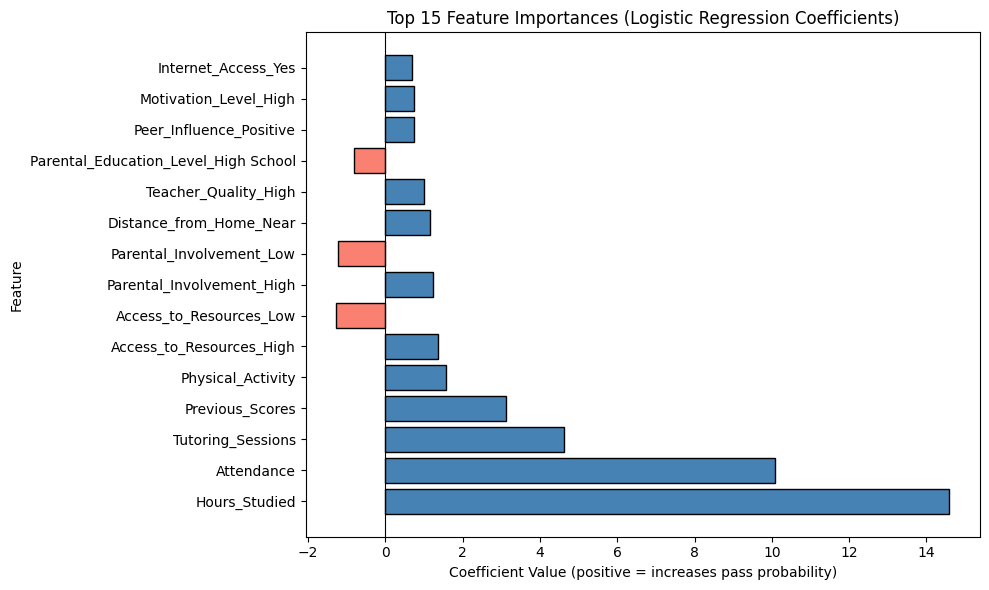

In [18]:
# Visualise top 15 feature importances as a horizontal bar chart
# Colour-coded: positive coefficients (increase pass probability) vs negative (decrease)
top_features = feature_importance.head(15)
colors = ['steelblue' if c > 0 else 'salmon' for c in top_features["Coefficient"]]

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Coefficient"], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=0.8)  # Reference line at zero
plt.title("Top 15 Feature Importances (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value (positive = increases pass probability)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 16. Logistic Regression – Confusion Matrix Visualisation

The confusion matrix for Logistic Regression is visualised using the same format as Naive Bayes, enabling direct visual comparison. Notably fewer false positives and false negatives are expected given the higher overall accuracy.

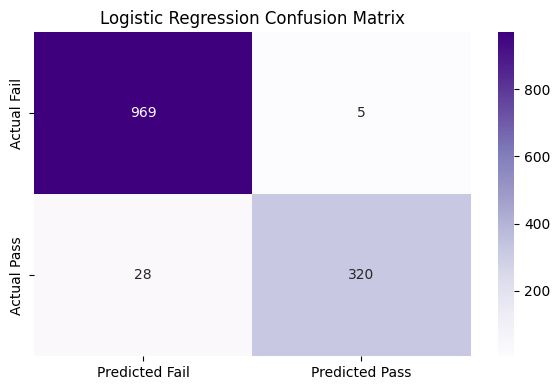

In [19]:
# Create confusion matrix heatmap for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Purples",       # Different colour to visually distinguish from NB heatmap
    xticklabels=["Predicted Fail", "Predicted Pass"],
    yticklabels=["Actual Fail", "Actual Pass"]
)
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

## 17. Model Comparison Summary

Both models are evaluated on identical data. This section consolidates results into a side-by-side comparison table and bar chart to directly compare their performance across all key metrics.

**Key observations to interpret:**
- The accuracy gap between models reflects Logistic Regression's ability to model feature correlations
- Recall for the minority class (Pass=1) is particularly important in the educational context — missing a student who is going to fail means missing the opportunity to intervene
- The class imbalance (~75% fail) means accuracy alone is not a reliable metric

In [20]:
# Build comparison metrics from classification reports
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate macro-averaged metrics (treats each class equally, regardless of size)
comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [
        round(accuracy_score(y_test, y_pred_nb), 4),
        round(accuracy_score(y_test, y_pred_lr), 4)
    ],
    "Precision (macro)": [
        round(precision_score(y_test, y_pred_nb, average='macro'), 4),
        round(precision_score(y_test, y_pred_lr, average='macro'), 4)
    ],
    "Recall (macro)": [
        round(recall_score(y_test, y_pred_nb, average='macro'), 4),
        round(recall_score(y_test, y_pred_lr, average='macro'), 4)
    ],
    "F1-Score (macro)": [
        round(f1_score(y_test, y_pred_nb, average='macro'), 4),
        round(f1_score(y_test, y_pred_lr, average='macro'), 4)
    ],
    "Pass Recall (Class 1)": [
        round(recall_score(y_test, y_pred_nb, pos_label=1), 4),
        round(recall_score(y_test, y_pred_lr, pos_label=1), 4)
    ]
})

print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
print(comparison.to_string(index=False))
print("=" * 80)

MODEL COMPARISON SUMMARY
              Model  Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)  Pass Recall (Class 1)
        Naive Bayes    0.8812             0.8451          0.8520            0.8484                 0.7902
Logistic Regression    0.9750             0.9783          0.9572            0.9671                 0.9195


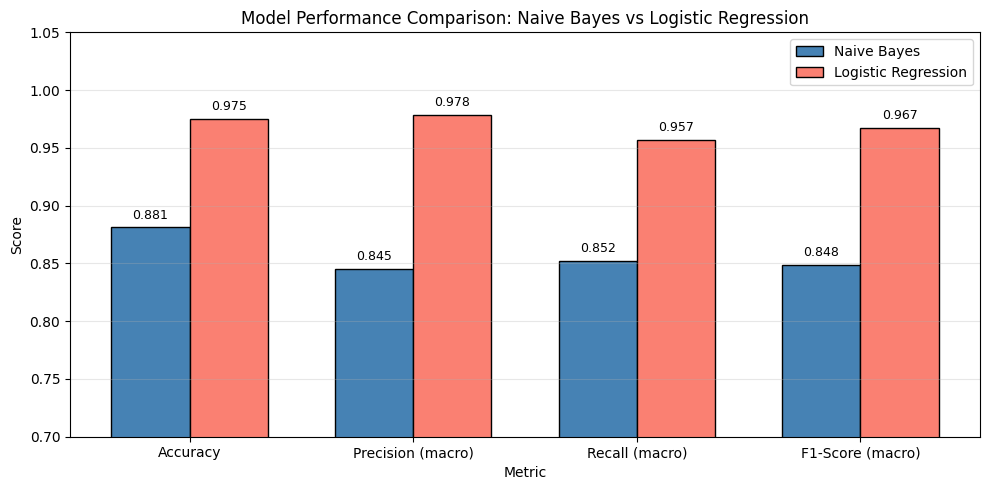

In [ ]:
# Visualise model comparison as a grouped bar chart
metrics = ["Accuracy", "Precision (macro)", "Recall (macro)", "F1-Score (macro)"]
nb_scores = comparison[comparison["Model"] == "Naive Bayes"][metrics].values[0]
lr_scores = comparison[comparison["Model"] == "Logistic Regression"][metrics].values[0]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, nb_scores, width, label='Naive Bayes', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, lr_scores, width, label='Logistic Regression', color='salmon', edgecolor='black')

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison: Naive Bayes vs Logistic Regression")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.7, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()